In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("✅ All imports successful!")

✅ All imports successful!


In [12]:
PROCESSED_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented"
MODEL_PATH     = r"D:\Development\8th Sem Project\TomatoClassification\models"
OUTPUT_PATH    = r"D:\Development\8th Sem Project\TomatoClassification\outputs"
IMAGE_SIZE     = (224, 224)
BATCH_SIZE     = 32
STRATEGY       = "D_finetuned"

model = load_model(os.path.join(MODEL_PATH, 'best_model_D_finetuned.h5'))

print(f"✅ Strategy {STRATEGY} model loaded!")
print(f"📊 Input shape  : {model.input_shape}")
print(f"📊 Output shape : {model.output_shape}")
print(f"📊 Total layers : {len(model.layers)}")

✅ Strategy D_finetuned model loaded!
📊 Input shape  : (None, 224, 224, 3)
📊 Output shape : (None, 10)
📊 Total layers : 158


In [13]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
class_names_short = [
    c.replace("Tomato___", "").replace("_", " ")
    for c in class_names
]

# Short display names for charts
short_names = [
    'Bacterial spot', 'Early blight', 'Late blight', 'Leaf Mold',
    'Septoria', 'Spider mites', 'Target Spot',
    'Yellow Curl', 'Mosaic virus', 'Healthy'
]

print(f"✅ Test data loaded!")
print(f"🧪 Total test images : {test_generator.samples}")
print(f"📋 Classes           : {len(class_names)}")
for i, name in enumerate(short_names):
    print(f"  {i:2d} → {name}")

Found 1399 images belonging to 10 classes.
✅ Test data loaded!
🧪 Total test images : 1399
📋 Classes           : 10
   0 → Bacterial spot
   1 → Early blight
   2 → Late blight
   3 → Leaf Mold
   4 → Septoria
   5 → Spider mites
   6 → Target Spot
   7 → Yellow Curl
   8 → Mosaic virus
   9 → Healthy


In [14]:
print(f"🔄 Evaluating Strategy {STRATEGY} on test set...\n")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*55}")
print(f"📊 Strategy {STRATEGY} — Test Results")
print(f"{'='*55}")
print(f"✅ Test Accuracy : {test_accuracy:.2%}")
print(f"📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*55}")

print(f"\n📈 All 4 Strategies Comparison:")
print(f"  Strategy A (Color only)    : 89.06% 🥇")
print(f"  Strategy D (Fine-tuned)    : {test_accuracy:.2%} 🥈")
print(f"  Strategy C (Mixed 50/50)   : 87.48%")
print(f"  Strategy B (Segmented only): 86.13% 🥉")
print(f"\n  D vs A : {(test_accuracy - 0.8906)*100:+.2f}%")
print(f"  D vs B : {(test_accuracy - 0.8613)*100:+.2f}%")
print(f"  D vs C : {(test_accuracy - 0.8748)*100:+.2f}%")

🔄 Evaluating Strategy D_finetuned on test set...

44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 612ms/step - accuracy: 0.8842 - loss: 0.3688

📊 Strategy D_finetuned — Test Results
✅ Test Accuracy : 88.42%
📉 Test Loss     : 0.3688

📈 All 4 Strategies Comparison:
  Strategy A (Color only)    : 89.06% 🥇
  Strategy D (Fine-tuned)    : 88.42% 🥈
  Strategy C (Mixed 50/50)   : 87.48%
  Strategy B (Segmented only): 86.13% 🥉

  D vs A : -0.64%
  D vs B : +2.29%
  D vs C : +0.94%


🔄 Generating predictions...
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 690ms/step


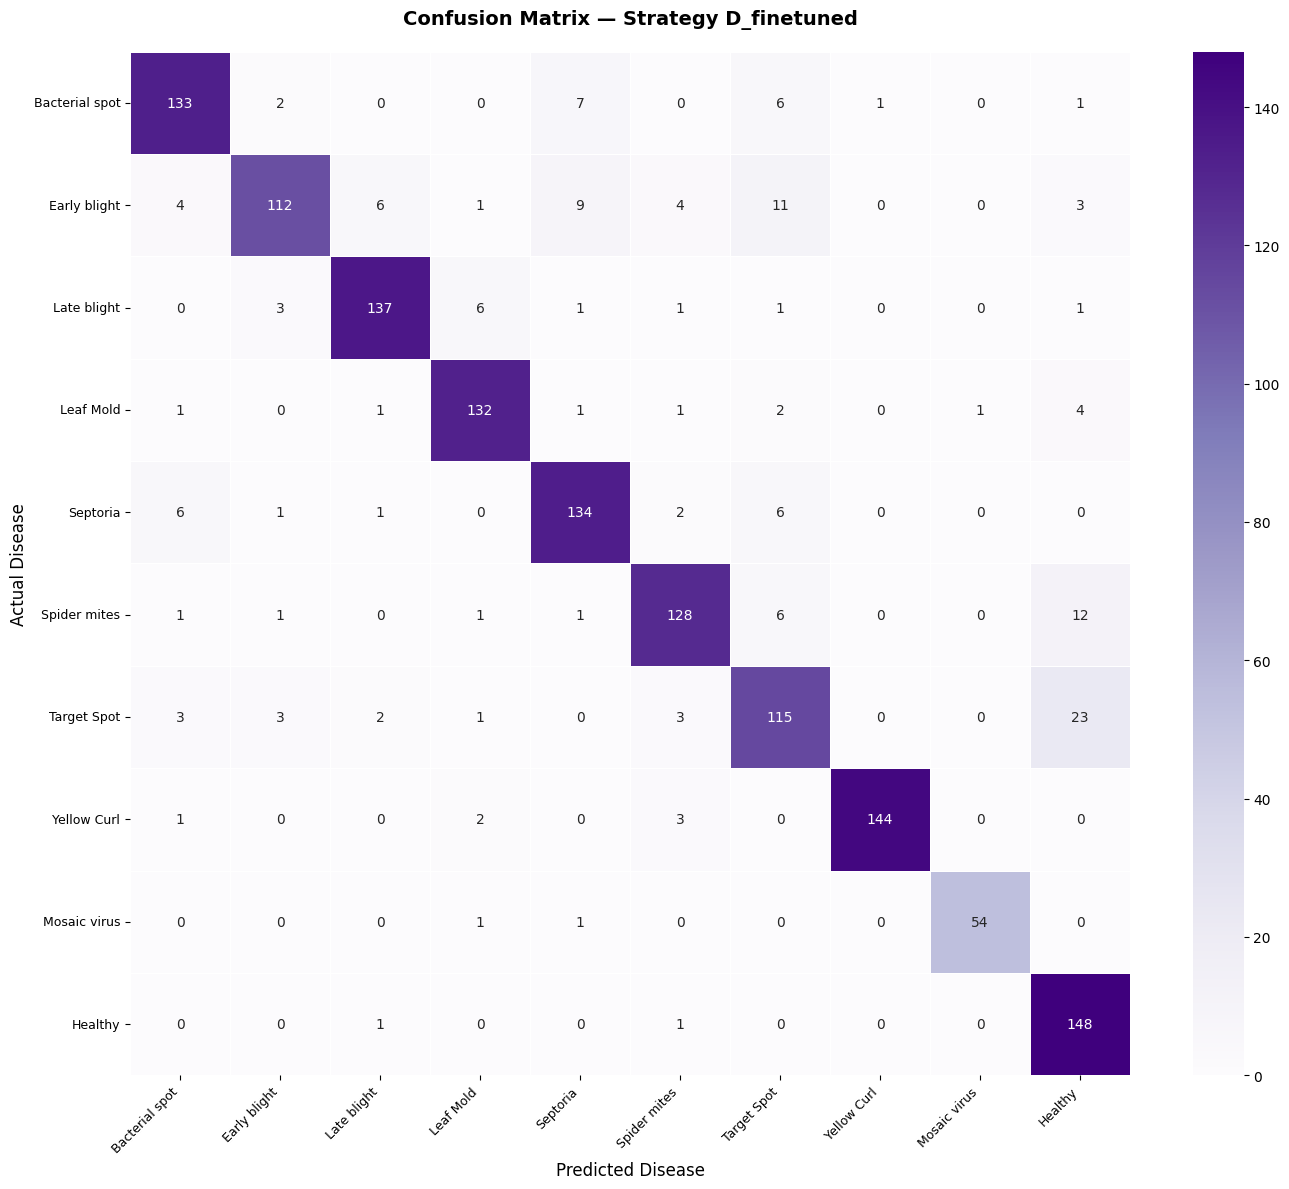

✅ Confusion matrix saved!


In [15]:
print("🔄 Generating predictions...")

predictions    = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes   = test_generator.classes
cm             = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Purples',        # Purple for Strategy D
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — Strategy {STRATEGY}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

os.makedirs(OUTPUT_PATH, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_PATH, f'confusion_matrix_{STRATEGY}.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

📋 Classification Report — Strategy D_finetuned

                precision    recall  f1-score   support

Bacterial spot      0.893     0.887     0.890       150
  Early blight      0.918     0.747     0.824       150
   Late blight      0.926     0.913     0.919       150
     Leaf Mold      0.917     0.923     0.920       143
      Septoria      0.870     0.893     0.882       150
  Spider mites      0.895     0.853     0.874       150
   Target Spot      0.782     0.767     0.774       150
   Yellow Curl      0.993     0.960     0.976       150
  Mosaic virus      0.982     0.964     0.973        56
       Healthy      0.771     0.987     0.865       150

      accuracy                          0.884      1399
     macro avg      0.895     0.889     0.890      1399
  weighted avg      0.889     0.884     0.884      1399



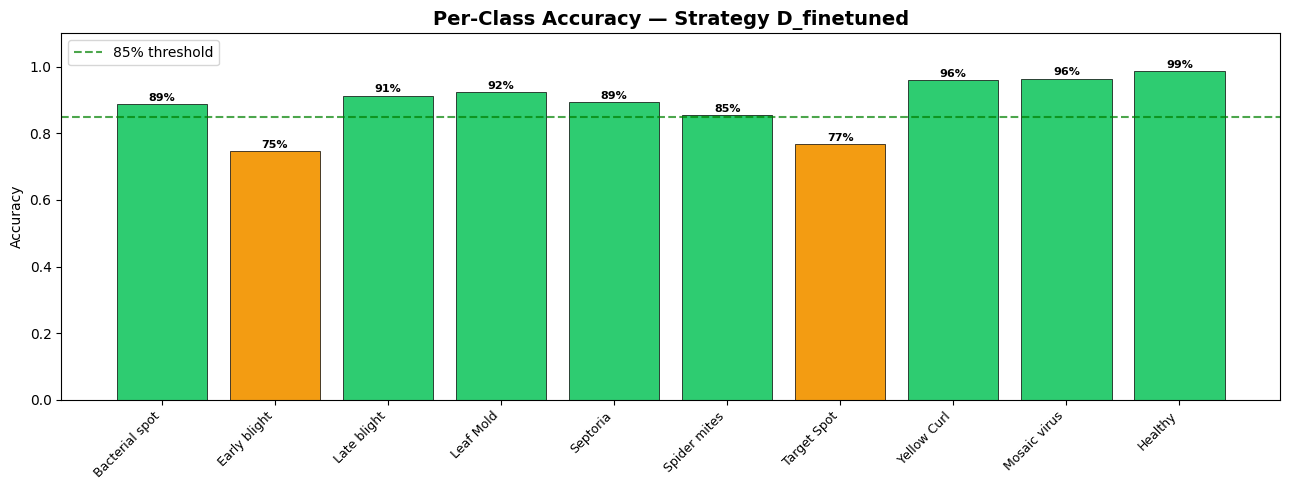

✅ Per-class chart saved!


In [16]:
report = classification_report(
    true_classes, predicted_classes,
    target_names=short_names, digits=3
)
print(f"📋 Classification Report — Strategy {STRATEGY}\n")
print(report)

# Per-class accuracy from confusion matrix
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(13, 5))
colors = ['#2ecc71' if acc >= 0.85 else '#f39c12' if acc >= 0.70
          else '#e74c3c' for acc in per_class_accuracy]

bars = plt.bar(short_names, per_class_accuracy,
               color=colors, edgecolor='black', linewidth=0.5)

plt.axhline(y=0.85, color='green', linestyle='--',
            alpha=0.7, label='85% threshold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Accuracy")
plt.title(f"Per-Class Accuracy — Strategy {STRATEGY}",
          fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend()

for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc:.0%}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, f'per_class_accuracy_{STRATEGY}.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class chart saved!")

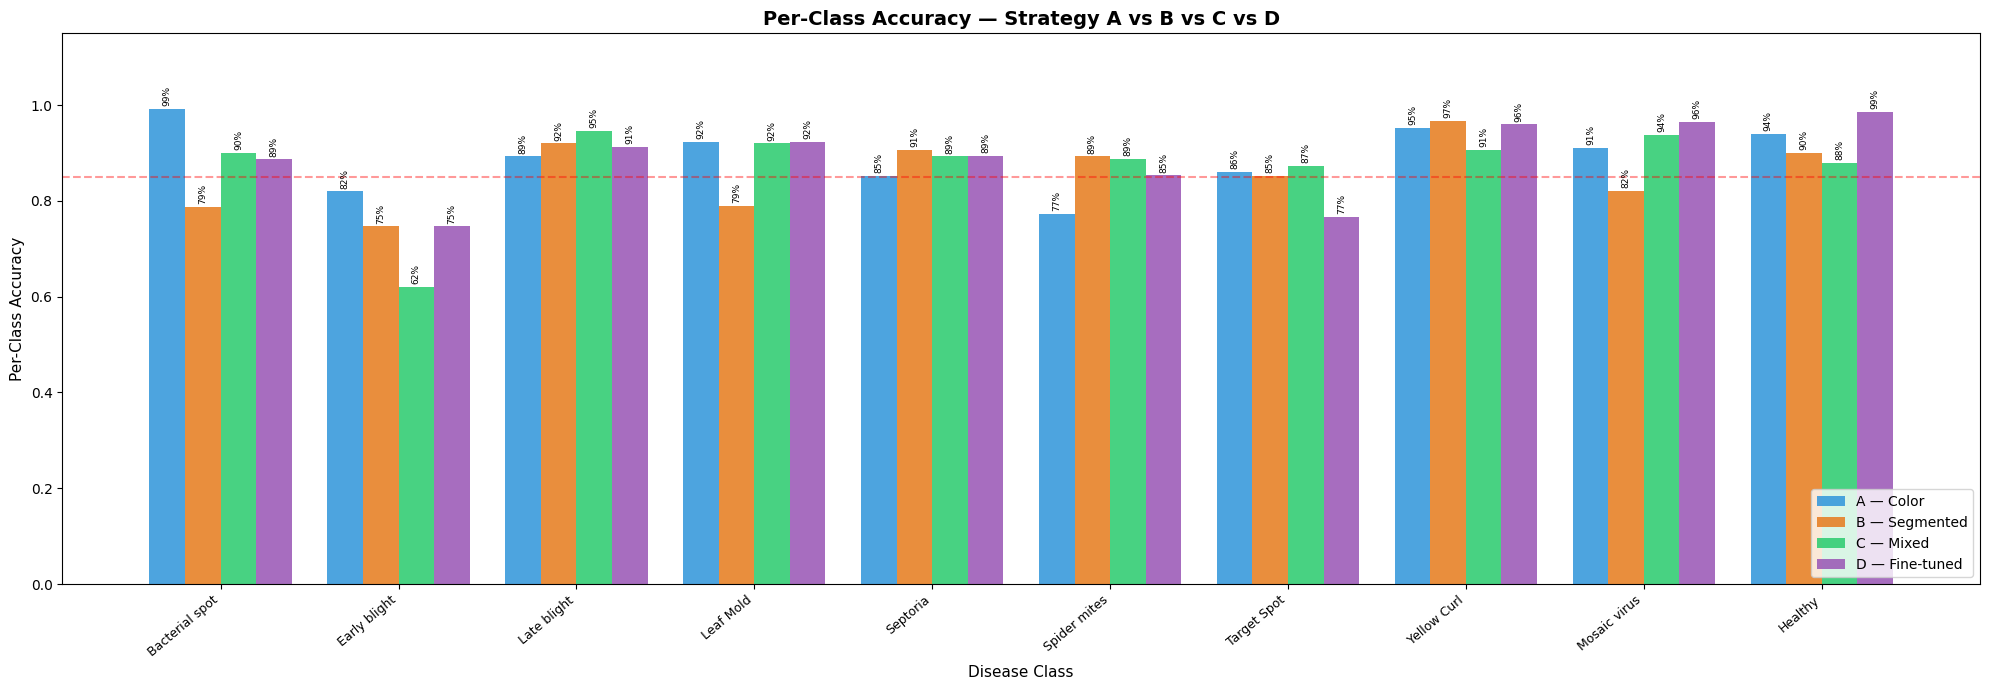

✅ 4-strategy comparison chart saved!


In [17]:
# ── All known per-class results ──────────────────────────────
strategy_A = {
    'Bacterial spot' : 0.993, 'Early blight'  : 0.820,
    'Late blight'    : 0.893, 'Leaf Mold'     : 0.923,
    'Septoria'       : 0.853, 'Spider mites'  : 0.773,
    'Target Spot'    : 0.860, 'Yellow Curl'   : 0.953,
    'Mosaic virus'   : 0.911, 'Healthy'       : 0.940
}

strategy_B = {
    'Bacterial spot' : 0.787, 'Early blight'  : 0.747,
    'Late blight'    : 0.920, 'Leaf Mold'     : 0.790,
    'Septoria'       : 0.907, 'Spider mites'  : 0.893,
    'Target Spot'    : 0.853, 'Yellow Curl'   : 0.967,
    'Mosaic virus'   : 0.821, 'Healthy'       : 0.900
}

strategy_C = {
    'Bacterial spot' : 0.900, 'Early blight'  : 0.620,
    'Late blight'    : 0.947, 'Leaf Mold'     : 0.920,
    'Septoria'       : 0.893, 'Spider mites'  : 0.887,
    'Target Spot'    : 0.873, 'Yellow Curl'   : 0.907,
    'Mosaic virus'   : 0.938, 'Healthy'       : 0.880
}

# Strategy D — from this evaluation's confusion matrix
strategy_D = dict(zip(short_names, per_class_accuracy))

# ── 4-bar grouped chart ───────────────────────────────────────
x     = np.arange(len(short_names))
width = 0.20

fig, ax = plt.subplots(figsize=(20, 7))

bars_A = ax.bar(x - 1.5*width, [strategy_A[n] for n in short_names],
                width, label='A — Color',     color='#3498db', alpha=0.88)
bars_B = ax.bar(x - 0.5*width, [strategy_B[n] for n in short_names],
                width, label='B — Segmented', color='#e67e22', alpha=0.88)
bars_C = ax.bar(x + 0.5*width, [strategy_C[n] for n in short_names],
                width, label='C — Mixed',     color='#2ecc71', alpha=0.88)
bars_D = ax.bar(x + 1.5*width, [strategy_D[n] for n in short_names],
                width, label='D — Fine-tuned',color='#9b59b6', alpha=0.88)

ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Per-Class Accuracy', fontsize=11)
ax.set_title('Per-Class Accuracy — Strategy A vs B vs C vs D',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10, loc='lower right')
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.4)
ax.set_ylim(0, 1.15)

# Value labels on top of bars
for bars_set in [bars_A, bars_B, bars_C, bars_D]:
    for bar in bars_set:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.0%}', ha='center', fontsize=6.5, rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'comparison_A_vs_B_vs_C_vs_D.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ 4-strategy comparison chart saved!")

In [18]:
print(f"\n{'Class':<20} {'A':>7} {'B':>7} {'C':>7} {'D':>7}  "
      f"{'D-A':>7} {'D-B':>7} {'D-C':>7}  {'Best':>10}")
print("─" * 95)

win_counts = {'A': 0, 'B': 0, 'C': 0, 'D': 0}

for cls in short_names:
    a = strategy_A[cls]
    b = strategy_B[cls]
    c = strategy_C[cls]
    d = strategy_D[cls]

    d_a = (d - a) * 100
    d_b = (d - b) * 100
    d_c = (d - c) * 100

    best_val = max(a, b, c, d)
    if   best_val == a: best = 'A 🔵'; win_counts['A'] += 1
    elif best_val == b: best = 'B 🟠'; win_counts['B'] += 1
    elif best_val == c: best = 'C 🟢'; win_counts['C'] += 1
    else:               best = 'D 🟣'; win_counts['D'] += 1

    da_arrow = '🟢' if d_a > 0 else '🔴'
    db_arrow = '🟢' if d_b > 0 else '🔴'
    dc_arrow = '🟢' if d_c > 0 else '🔴'

    print(f"{cls:<20} {a:>7.1%} {b:>7.1%} {c:>7.1%} {d:>7.1%}  "
          f"{da_arrow}{d_a:>+5.1f}% {db_arrow}{d_b:>+5.1f}% "
          f"{dc_arrow}{d_c:>+5.1f}%  {best:>10}")

print("─" * 95)
print(f"\n{'OVERALL':<20} {'89.1%':>7} {'86.1%':>7} {'87.5%':>7} "
      f"{test_accuracy:>7.1%}")

print(f"\n🏆 Class-level wins across all 4 strategies:")
print(f"   Strategy A (Color)      → {win_counts['A']}/10 classes 🔵")
print(f"   Strategy B (Segmented)  → {win_counts['B']}/10 classes 🟠")
print(f"   Strategy C (Mixed)      → {win_counts['C']}/10 classes 🟢")
print(f"   Strategy D (Fine-tuned) → {win_counts['D']}/10 classes 🟣")


Class                      A       B       C       D      D-A     D-B     D-C        Best
───────────────────────────────────────────────────────────────────────────────────────────────
Bacterial spot         99.3%   78.7%   90.0%   88.7%  🔴-10.6% 🟢+10.0% 🔴 -1.3%         A 🔵
Early blight           82.0%   74.7%   62.0%   74.7%  🔴 -7.3% 🔴 -0.0% 🟢+12.7%         A 🔵
Late blight            89.3%   92.0%   94.7%   91.3%  🟢 +2.0% 🔴 -0.7% 🔴 -3.4%         C 🟢
Leaf Mold              92.3%   79.0%   92.0%   92.3%  🟢 +0.0% 🟢+13.3% 🟢 +0.3%         D 🟣
Septoria               85.3%   90.7%   89.3%   89.3%  🟢 +4.0% 🔴 -1.4% 🟢 +0.0%         B 🟠
Spider mites           77.3%   89.3%   88.7%   85.3%  🟢 +8.0% 🔴 -4.0% 🔴 -3.4%         B 🟠
Target Spot            86.0%   85.3%   87.3%   76.7%  🔴 -9.3% 🔴 -8.6% 🔴-10.6%         C 🟢
Yellow Curl            95.3%   96.7%   90.7%   96.0%  🟢 +0.7% 🔴 -0.7% 🟢 +5.3%         B 🟠
Mosaic virus           91.1%   82.1%   93.8%   96.4%  🟢 +5.3% 🟢+14.3% 🟢 +2.6%         D 🟣
Hea

In [19]:
print("🔬 KEY RESEARCH OBSERVATIONS — Strategy D\n")
print("=" * 60)

# Auto-analyze each class
observations = []
for cls in short_names:
    a = strategy_A[cls]
    b = strategy_B[cls]
    d = strategy_D[cls]
    d_a = (d - a) * 100
    d_b = (d - b) * 100

    if d_a > 5:
        obs = f"✅ {cls}: D improved over A by {d_a:+.1f}% — fine-tuning helped"
    elif d_a < -5:
        obs = f"⚠️  {cls}: D dropped vs A by {d_a:+.1f}% — some forgetting occurred"
    elif abs(d_a) <= 1:
        obs = f"➡️  {cls}: D matched A ({d_a:+.1f}%) — color knowledge fully retained"
    else:
        obs = f"🟡 {cls}: D minor change vs A ({d_a:+.1f}%)"

    observations.append(obs)
    print(obs)

print("\n" + "=" * 60)
print(f"\n📊 Summary:")
print(f"  Fine-tuning improved over Strategy A in : "
      f"{sum(1 for o in observations if '✅' in o)}/10 classes")
print(f"  Fine-tuning matched Strategy A in       : "
      f"{sum(1 for o in observations if '➡️' in o)}/10 classes")
print(f"  Fine-tuning dropped vs Strategy A in    : "
      f"{sum(1 for o in observations if '⚠️' in o)}/10 classes")

print(f"\n💡 Catastrophic Forgetting Check:")
print(f"  Strategy A original accuracy  : 89.06%")
print(f"  Strategy D current accuracy   : {test_accuracy:.2%}")
print(f"  Knowledge retained            : {(test_accuracy/0.8906)*100:.1f}%")

if test_accuracy >= 0.88:
    print(f"  Verdict: ✅ Fine-tuning successful — minimal forgetting")
elif test_accuracy >= 0.84:
    print(f"  Verdict: 🟡 Acceptable — minor forgetting, still competitive")
else:
    print(f"  Verdict: 🔴 Significant forgetting detected")

🔬 KEY RESEARCH OBSERVATIONS — Strategy D

⚠️  Bacterial spot: D dropped vs A by -10.6% — some forgetting occurred
⚠️  Early blight: D dropped vs A by -7.3% — some forgetting occurred
🟡 Late blight: D minor change vs A (+2.0%)
➡️  Leaf Mold: D matched A (+0.0%) — color knowledge fully retained
🟡 Septoria: D minor change vs A (+4.0%)
✅ Spider mites: D improved over A by +8.0% — fine-tuning helped
⚠️  Target Spot: D dropped vs A by -9.3% — some forgetting occurred
➡️  Yellow Curl: D matched A (+0.7%) — color knowledge fully retained
✅ Mosaic virus: D improved over A by +5.3% — fine-tuning helped
🟡 Healthy: D minor change vs A (+4.7%)


📊 Summary:
  Fine-tuning improved over Strategy A in : 2/10 classes
  Fine-tuning matched Strategy A in       : 2/10 classes
  Fine-tuning dropped vs Strategy A in    : 3/10 classes

💡 Catastrophic Forgetting Check:
  Strategy A original accuracy  : 89.06%
  Strategy D current accuracy   : 88.42%
  Knowledge retained            : 99.3%
  Verdict: ✅ Fine-tun

In [20]:
results_path = os.path.join(OUTPUT_PATH, 'results_summary.txt')

with open(results_path, 'a') as f:
    f.write(f"\nStrategy {STRATEGY} — Evaluation\n")
    f.write(f"  Test Accuracy    : {test_accuracy:.4f}\n")
    f.write(f"  Test Loss        : {test_loss:.4f}\n")
    f.write(f"  Classification Report:\n{report}\n")

print(f"✅ Evaluation complete!")
print(f"\n📁 Files saved to outputs/:")
print(f"   confusion_matrix_{STRATEGY}.png")
print(f"   per_class_accuracy_{STRATEGY}.png")
print(f"   comparison_A_vs_B_vs_C_vs_D.png   ← main research chart")
print(f"   results_summary.txt               ← updated")

print(f"\n📊 Final 4-Strategy Leaderboard:")
results = {
    'A — Color'     : 89.06,
    'D — Fine-tuned': test_accuracy * 100,
    'C — Mixed'     : 87.48,
    'B — Segmented' : 86.13,
}
for i, (name, acc) in enumerate(
        sorted(results.items(), key=lambda x: x[1], reverse=True), 1):
    medal = ['🥇','🥈','🥉','  '][i-1]
    print(f"  {medal} {name:<18} : {acc:.2f}%")

✅ Evaluation complete!

📁 Files saved to outputs/:
   confusion_matrix_D_finetuned.png
   per_class_accuracy_D_finetuned.png
   comparison_A_vs_B_vs_C_vs_D.png   ← main research chart
   results_summary.txt               ← updated

📊 Final 4-Strategy Leaderboard:
  🥇 A — Color          : 89.06%
  🥈 D — Fine-tuned     : 88.42%
  🥉 C — Mixed          : 87.48%
     B — Segmented      : 86.13%
